## Intercomparison of inverse modelling results

This notebook contains options to plot and compare results from different inverse models. The following variables can be investigated:

- Posterior and prior country fluxes, total from all sectors, and respective uncertainties
- Observed and posterior/prior modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior bias mole fractions
- Posterior and prior mole fractions from the outer regions
- Observed repeatability/variability, model and total uncertainties
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Input data:

- Flux and concentration netCDF files with model outputs
- json files with models, sites and species information
- (optional) netCDF file with country fluxes from bottom-up inventory
- (optional) netCDF file with baseline timestamps

Please refer to the User Guide for information on files format, filename convention and folder structure.

### Notebook setup:

1. Decide the verbosity level by assigning the logging level to `logging.INFO` or `logging.WARNING`.

2. Edit the `data_dir` to point towards where the model output is.

3. Set `presentation_mode` to `True`/`False` to use big font sizes (recommended for slides) or small font sizes (recommended for text documents). 

4. Update the `experiments` dictionary so that each key points towards the models you want to plot.

5. Run the cell below, before running any of the plotting code.

In [1]:
%load_ext autoreload
%autoreload 2
import logging
logging.basicConfig(level=logging.INFO)

from fluxie.config import set_print_settings
from fluxie.io import read_config_files

### Path to results directory
data_dir = '/data/users/intem_ghg/inversion/PARIS_results_sharing'

### Set presentation_mode to True for bigger fonts
presentation_mode = False

### Group the models of interest in meaningful experiment names 
experiments = {'std_run'       :['InTEM_NAME_EUROPE_EDGAR_std', 'ELRIS_NAME_EUROPE_EDGAR_std', 'RHIME_NAME_EUROPE_EDGAR_std'],
               'wetcharts'     :['InTEM_NAME_EUROPE_EDGARWETCHART_31sites_std','ELRIS_NAME_EUROPE_EDGARWETCHART_31base',
                                 'RHIME_NAME_EUROPE_EDGAR-WetCHARTs_std_31sites']
              }

###################################

config_data = read_config_files()
annotate_coords = set_print_settings(presentation_mode)

INFO:numexpr.utils:NumExpr defaulting to 4 threads.
INFO:fluxie.io:Reading config files from /home/users/alice.ramsden/fluxie/configs


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to read and pre-process the data:

In [ ]:
from fluxie.io import read_model_output, read_flux_total_fgases
from fluxie.operators.select import slice_flux
from fluxie.config import set_model_colors
from fluxie.config import set_model_labels
from fluxie.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
species = 'ch4' #options for individual species, or 'all_hfc' or 'all_pfc'
models = ['InTEM_ERA5_EUROPE_NID2026_G',
#          'InTEM_NAME_EUROPE_NID2026_annual',
          'InTEM_NAME_EUROPE_AR2026']
#models = ['InTEM_NAME_EUROPE_AR2026']
regions = ['UK']
period = ['yearly','monthly'] #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
country_flux_units_print = 'Tg yr-1 CO2-eq' #desired units for the plot. Add "CO2-eq" to convert the mass to CO2 equivalent (e.g. "Gg CO2-eq yr-1")
#start_date = ['2010-01-01','2010-01-01','2012-01-01']#,'2012-01-01'] #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
#end_date = ['2012-01-01','2012-01-01','2026-01-01']#,'2025-01-01'] #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year
start_date = ['1990-01-01','2012-01-01']
end_date = ['2012-01-01','2026-01-01']
get_labels_from_file = True # If False, uses default labels. If True, uses labels in models_info.json.
sector_file = 'EUROPE_EDGAR_v2025_CEH_ch4_monthly'  # if not None, adds sector level results by scaling model totals by the sector proportions in this file. Default file: 'EUROPE_EDGAR', inside the 'sector_flux' directory
create_region_sector_totals = True #if True, uses country_fraction variable to sum spatial sector fluxes to region sector fluxes
create_sectors = True
read_standard_run = False
only_overlapping = False #if True, only uses time periods where all models have data
sectors = ['agriculture','waste','energy','industry','natural']
###################################

if 'all' in species:
    ds_all_flux_scaled = read_flux_total_fgases(data_dir,species,models,config_data,
                                                     regions,start_date,end_date,
                                                     period=period,only_overlapping=only_overlapping)
else:
    ds_all_flux = read_model_output(data_dir,"flux",species,models,config_data,period=period,read_standard_run=read_standard_run)
    ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,country_flux_units_print=country_flux_units_print)

if sector_file is not None:
    ds_all_flux_scaled = scale_by_sector_proportions(data_dir=data_dir,ds_all=ds_all_flux_scaled,
                                                            species=species,
                                                            country_flux_units_print=country_flux_units_print,
                                                            config_data=config_data,regions=regions,
                                                            sector_file=sector_file,create_sectors=create_sectors,
                                                            create_region_sector_totals=create_region_sector_totals,
                                                            sectors=sectors)   

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

In [ ]:
from fluxie.io import read_model_output, read_flux_total_fgases
from fluxie.operators.select import slice_flux
from fluxie.config import set_model_colors
from fluxie.config import set_model_labels
from fluxie.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
species = 'sf6' #options for individual species, or 'all_hfc' or 'all_pfc'
models = ['InTEM_NAME_EUROPE_inv_b_GerFac']
regions = ['NW_EU2','DEU','GermanFactory']
period = ['3monthly'] #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
country_flux_units_print = 'Tg yr-1 CO2-eq' #desired units for the plot. Add "CO2-eq" to convert the mass to CO2 equivalent (e.g. "Gg CO2-eq yr-1")
start_date = ['2010-01-01']#,'2012-01-01'] #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = ['2026-01-01']#,'2025-01-01'] #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year
get_labels_from_file = True # If False, uses default labels. If True, uses labels in models_info.json.
sector_file = None #'EUROPE_EDGAR_GBR_IRL'  # if not None, adds sector level results by scaling model totals by the sector proportions in this file. Default file: 'EUROPE_EDGAR', inside the 'sector_flux' directory
create_region_sector_totals = True #if True, uses country_fraction variable to sum spatial sector fluxes to region sector fluxes
create_sectors = True
read_standard_run = False
only_overlapping = False #if True, only uses time periods where all models have data
sectors = ['agriculture','waste','energy','industry']
###################################

if 'all' in species:
    ds_all_flux_scaled = read_flux_total_fgases(data_dir,species,models,config_data,
                                                     regions,start_date,end_date,
                                                     period=period,only_overlapping=only_overlapping)
else:
    ds_all_flux = read_model_output(data_dir,"flux",species,models,config_data,period=period,read_standard_run=read_standard_run)
    ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,country_flux_units_print=country_flux_units_print)

if sector_file is not None:
    ds_all_flux_scaled = scale_by_sector_proportions(data_dir=data_dir,ds_all=ds_all_flux_scaled,
                                                            species=species,
                                                            country_flux_units_print=country_flux_units_print,
                                                            config_data=config_data,regions=regions,
                                                            sector_file=sector_file,create_sectors=create_sectors,
                                                            create_region_sector_totals=create_region_sector_totals,
                                                            sectors=sectors)   

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

#### Timeseries of country fluxes:

In [ ]:
from fluxie.plots.flux_timeseries import plot_country_flux

###################################
### edit variables in this block
plot_inventory = True
plot_inventory_uncertainty = [False]    #Either True/False or a list of True/False to match length of inventory_years
inventory_years = ['2026'] #If None, plots most recent. Or can choose list of years: ['2022','2023']
inventory_filename = 'UNFCCC_inventory'   #Full filename = {inventory_filename}_{species}_{inventory_year}
fix_y_axes = False #[0,75] #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior = False #if True: plots prior as dashed lines
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = False #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles. Set to None for no title.
plot_separate = False #If True, includes all model results as separate lines (or insert a list of boolean of the same length as models to specify which models to plot)
plot_separate_unc = True #If True, includes all model uncertainty as shaded areas
plot_combined = True #If True, combined results, averaged from all models (or insert a list of boolean of the same length as models to specify which models to combine)
combined_models_dict = None #To plot multiple combined results, use (e.g.) combined_models_dict = {'NAME Mean': ['InTEM_NAME', 'ELRIS_NAME'], 'FLEXPART Mean': ['InTEM_FLEXPART', 'ELRIS_FLEXPART']} and set plot_combined = True.
plot_combined_unc = False #If True, includes combined uncertainty as shaded area
resample = [None,'year'] #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation.
plot_resample_and_original = False #If True, plots both the resampled and original data
annex_mode = False #If True, replace the labels with more concise versions for NID Annexes.
rolling_mean = [3,False] # If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
sector = 'agriculture'     # default 'total', otherwise chosen single sector plotted for all models
aggreg_month = False     # if True, plot the fluxes aggregated by month. Only work with monthly data.
xticks_at_centre = True    # if True, moves x ticks to centre of time periods
plot_grid = False    # if True, adds faint grid to the plots
###################################

fig,res = plot_country_flux(ds_all_flux_scaled,
                        species,
                        regions,
                        config_data,
                        model_colors,
                        model_labels,
                        start_date,
                        end_date,
                        annex_mode,
                        plot_inventory,
                        plot_inventory_uncertainty,
                        inventory_years,
                        inventory_filename,
                        data_dir,
                        fix_y_axes,
                        add_prior,
                        add_prior_unc,
                        set_global_leg,
                        country_codes_as_titles=country_codes_as_titles,
                        plot_separate=plot_separate,
                        plot_separate_unc=plot_separate_unc,
                        plot_combined=plot_combined,
                        combined_models_dict = combined_models_dict,
                        plot_combined_unc=plot_combined_unc,
                        resample=resample,
                        resample_uncert_correlation=resample_uncert_correlation,
                        plot_resample_and_original=plot_resample_and_original,
                        rolling_mean=rolling_mean,
                        aggreg_month=aggreg_month,
                        return_res=True,sector=sector,
                        xticks_at_centre=xticks_at_centre,
                        plot_grid=plot_grid,
                        only_overlapping=only_overlapping)

In [ ]:
#output_path = f'/home/users/alice.ramsden/plots/NID_AR_plots/2026/ch4_ERAInterim_vs_ERA5_scaled_by_EDGAR_{sector}.png'
output_path = f'/home/users/alice.ramsden/plots/NID_AR_plots/ch4_onos/ch4_InTEM_ERA5_UKV_EDGAR_{sector}_scaling_AR2026.png'


fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Table of country flux, combining monthly and yearly results into one timeseries

The cell to plot the timeseries must be run first, with return_res=True, plot_inventory=True and plot_inventory_uncertainty=True.

Then the cells below can be run, to create the table file.

You may need to adjust the 'country_flux_units_print' variable, for each species.

In [ ]:
from fluxie.cli.MO_annual_report import make_AR_table

###################################
### edit variables in this block
output_dir = '/home/users/alice.ramsden/plots/NID_AR_plots/ch4_onos'
output_name = f'ch4_InTEM_ERA5_UKV_{sector}_AR2026'
n_digits = 2 #number of decimal places includes in the table values
###################################

all_sp_res = make_AR_table(df=res,output_dir=output_dir,output_name=output_name,
              inventory_years=inventory_years,species=species,
              s_data=config_data["species_info"],regions=regions,start_date=start_date,
              country_flux_units_print=country_flux_units_print,
              include_inventory_uncert=plot_inventory_uncertainty[0],
              include_inventory=plot_inventory,n_digits=2,
              save_csv=True,sector=sector
              )

#### Timeseries of sector country fluxes - as bar charts

In [ ]:
from fluxie.plots.flux_timeseries import plot_country_sector_flux_bar

###################################
### edit variables in this block
plot_region = 'UK'
plot_inventory_or_prior = 'inventory'
inventory_years = ['2026'] #If None, plots most recent. Or can choose list of years: ['2022','2023']
inventory_filename = 'UNFCCC_inventory'   #Full filename = {inventory_filename}_{species}_{inventory_year}
fix_y_axes = [0,145] #[0,3] #[0,5.5] #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior = True #if True: plots prior as dashed lines
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles. Set to None for no title.
resample = 'year' #If None, no resample is done. Else resample the data to the given period (options 'year' aJnd 'season' for yearly and seasonal averages)
resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation.
plot_resample_and_original = False #If True, plots both the resampled and original data
annex_mode = True #If True, replace the labels with more concise versions for NID Annexes.
rolling_mean = False ##If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
sectors = {"model":['agriculture','energy','waste','industry','natural'],
           "inventory":['agriculture','energy','waste','land']}
xticks_at_centre = True    # if True, moves x ticks to centre of time periods
plot_grid = False
gaps_between_bars = True
plot_separate = True
plot_combined = False
only_overlapping = False
vertical_line = None #'2011-12-01'
###################################

fig = plot_country_sector_flux_bar(ds_all=ds_all_flux_scaled,species=species,plot_region=plot_region,
                                   config_data=config_data,model_labels=model_labels,
                                   plot_inventory_or_prior=plot_inventory_or_prior,
                                   inventory_years=inventory_years,inventory_filename=inventory_filename,
                                   data_dir=data_dir,fix_y_axes=fix_y_axes,
                                   resample=resample,resample_uncert_correlation=resample_uncert_correlation,
                                   rolling_mean=rolling_mean,sectors=sectors,
                                   xticks_at_centre=xticks_at_centre,plot_grid=plot_grid,
                                   gaps_between_bars=gaps_between_bars,
                                   plot_separate=plot_separate,
                                   plot_combined=plot_combined,
                                   only_overlapping=only_overlapping,
                                   annex_mode=annex_mode,
                                   vertical_line=vertical_line)

Save plot here:

In [ ]:
#output_path = '/home/users/alice.ramsden/plots/InTEM_scaled-by-EDGAR_ERA5-annual-3-rolling_monthly-annualised_with_nsites.png'
output_path = '/home/users/alice.ramsden/plots/InTEM_scaled-by-CEH-monthly-annualised.png'


fig[0].savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

In [ ]:
import xarray as xr
o = xr.open_dataset('/home/users/alice.ramsden/data_intem_ghg/PARIS_results_sharing/PRIOR/ch4/PRIOR_EUROPE_EDGAR_CEH_GBR_IRL_ch4_monthly.nc')
o

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(o.time.values,np.nansum(o['flux_agriculture_prior'],axis=(1,2)))

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
from fluxie.io import read_model_output
from fluxie.operators.select import slice_mf
from fluxie.config import set_model_colors
from fluxie.config import set_model_labels

###################################
### edit variables in this block
species = 'sf6' 
site = None #'TAC'
intake_height = None
models = ['InTEM_NAME_EUROPE_inv_c_GerFac']
period = '3monthly'  #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
mf_units_print = 'ppt'
start_date = '2024-01-01' #inclusive
end_date = '2025-01-01'   #not inclusive
baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
baseline_filename = 'InTEM_baseline_timestamps'
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.
read_standard_run = False
###################################

ds_all_mf = read_model_output(data_dir,'concentration',species,models,config_data,period=period,read_standard_run=read_standard_run)

ds_all_mf_sliced = slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              baseline_filename=baseline_filename,data_dir=data_dir,
                              mf_units_print=mf_units_print,intake_height=intake_height)

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

#### Plot timestamps with data at each site:

In [ ]:
from fluxie.plots.mf_timeseries import plot_sites_timeseries

separate_by_height = False      #If True, plots data split by site and by height

fig = plot_sites_timeseries(ds_all_mf,'mf_posterior',species,start_date,end_date,model_colors,model_labels,config_data,margin=0.2,
                            separate_by_height=separate_by_height)

Save plot:

In [ ]:
output_path = '/home/users/alice.ramsden/home_intem_ghg/NID_2026/NID2025_comparison_plots/hfc125_obs_availablility_NID2025_NID2026.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, separated by model:

In [ ]:
from fluxie.plots.mf_timeseries import plot_timeseries

###################################
### edit variables in this block
# Variables and respective uncertainties to plot
include = {'mf_observed'   : None,
           'mf_posterior' : 'percentile_mf_posterior'
           }

# To plot the histogram of the variables in "include", set "diff_include" to None
# To plot the histogram of Obs-variable, set "diff_include" to the desired variable to be subtracted
diff_include = ['mf_posterior']

y_lim = None # to choose y-axis limits set y_lim=[min_value,max_value]
aggreg_month = False # set to true to aggregate mf data by month and see the seasonnal cycle
###################################

###################################
### options for variables to include
# mf_observed         - total observed mole fraction
# mf_prior            - prior total mole fraction
# mf_posterior        - posterior total mole fraction
# mf_bc_prior         - prior baseline
# mf_bc_posterior     - posterior baseline
# mf_bias_prior       - prior bias added to site
# mf_bias_posterior   - posterior bias added to site
# mf_outer_prior      - prior mole fractions only from outer regions
# mf_outer_posterior  - posterior mole fractions only from outer regions
# stdev_mf_observed_repeatability - observed repeatability mole fraction uncertainty
# stdev_mf_observed_variability   - observed variability mole fraction uncertainty
# stdev_mf_model                  - model mole fraction uncertainty
# stdev_mf_total                  - total mole fraction uncertainty

### options for uncertainties to plot as error bars/shaded area
# stdev_mf_observed_repeatability - observed repeatability mole fraction uncertainty
# stdev_mf_observed_variability   - observed variability mole fraction uncertainty
# stdev_mf_model                  - model mole fraction uncertainty
# stdev_mf_total                  - total mole fraction uncertainty
# percentile_mf_prior             - prior mole fraction uncertainty
# percentile_mf_posterior         - posterior mole fraction uncertainty
###################################

fig = plot_timeseries(ds_all_mf_sliced,include,species,site,
                                    model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                                    plot_type='separate',
                                    diff_include=diff_include,
                                    y_lim=y_lim,intake_height=intake_height,aggreg_month=aggreg_month)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/mf_posterior_timeseries.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
from fluxie.plots.mf_timeseries import plot_timeseries

###################################
### edit variables in this block (see instructions above)
#include = {'mf_observed':None,
#           'mf_posterior' : 'percentile_mf_posterior'}
include = {'mf_observed':None,
           'mf_bc_posterior' : None}

diff_include=['mf_posterior']
y_lim=None
###################################

fig = plot_timeseries(ds_all_mf_sliced,include,species,site,
                                    model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                                    plot_type='together',
                                    diff_include=diff_include,
                                    y_lim=y_lim,intake_height=intake_height)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/mf_posterior_allmodels.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Absolute differences between two models:

In [ ]:
from fluxie.operators.mf import compute_mf_difference
from fluxie.plots.mf_timeseries import plot_timeseries

###################################
### edit variables in this block
models_to_subtract = models[:2] # Models to subtract (must be a list of 2 elements)
include = {'mf_observed': None}        # Variables to plot (dict values must be set to None)
###################################

ds_diff = compute_mf_difference(ds_all_mf_sliced.copy(), models_to_subtract)

fig = plot_timeseries(ds_diff,include,species,site,
                        model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                        plot_type='diff',
                        diff_include=None,
                        y_lim=None,intake_height=intake_height)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/mf_posterior_diff.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Calculate and plot stats for the fit to obs:

In [ ]:
from fluxie.operators.select import slice_mf
from fluxie.operators.mf import stats_mf
from fluxie.plots.mf_stats import plot_stats_mf


###################################
### edit variables in this block
stats_to_plot = ['pearson', 'bias', 'crmse']
what_to_compare = 'posterior_above_BC'
stats_ylim = {"pearson": [0,1], "bias": [-1.5,0.5], "crmse": [0,1.5] }    # or set it to None
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.


### Implemented statistics (stats_to_plot)
# pearson - Pearson correlation coefficient
# bias    - Mean difference
# rmse    - RMSE
# nrmse   - Normalised RMSE (division by mean observation)
# crmse   - Centered (bias-corrected) RMSE
# std_obs  - Standard deviation of observations 
# std_sim  - Standard deviation of simulation 
# std_res  - Standard deviation of residuals
# nn      - Number of observation-simulation pairs 
###################################

ds_all_allsites = slice_mf(ds_all_mf.copy(), 
                        start_date,
                        end_date,site=None,
                        baseline_site=baseline_site,
                        baseline_filename=baseline_filename,
                        data_dir=data_dir,
                        mf_units_print=mf_units_print)

model_labels = set_model_labels(models,config_data,get_labels_from_file)

stats = stats_mf(ds_all_allsites, stats_type=what_to_compare)

fig = plot_stats_mf(stats=stats, 
                    stats_to_plot=stats_to_plot, 
                    species=species,
                    model_colors=model_colors, 
                    model_labels=model_labels, 
                    config_data=config_data, 
                    mf_units_print=mf_units_print,
                    stats_type=what_to_compare,
                    stats_ylim=stats_ylim,
                    start_date=start_date, 
                    end_date=end_date)

#### Plot Taylor Diagrams

In [ ]:
from fluxie.operators.mf import stats_mf
from fluxie.plots.mf_stats import plot_taylor_diagram

###################################
### edit variables in this block
include = ['posterior'] # Variables to include in the Taylor diagram
plot_type_model = 'together' #  If 'separate', plots each model in a separate subplot. If 'together', plots all models in the same subplot.
plot_type_stat = 'together'  # If 'separate', plots each statistic in a separate subplot. If 'together', plots all statistics in the same subplot.
normalize = True # If True, normalizes the data by the standard deviation of the observations. If False, plots the absolute data.
stat_markers = ['s'] # Marker styles used to plot the stats specified in the `include` parameter, sharing the same index. 
std_range = [0, 1.5] # Range for the standard deviation axis, in units provided with `std_unit` if `normalize` = True.
check_sites = True # If True, color different sites with different colors
###################################

model_labels = set_model_labels(models, config_data, get_labels_from_file)

stats = {}
for stat in include:
    stats[stat] = stats_mf(ds_all_allsites, stats_type=stat)

fig = plot_taylor_diagram(
    stats=stats,
    model_colors=model_colors,
    model_labels=model_labels,
    stat_markers=stat_markers,
    normalize=normalize,
    plot_type_model=plot_type_model,
    plot_type_stat=plot_type_stat,
    include=include,
    std_range=std_range,
    std_unit=mf_units_print,
    check_sites=check_sites
)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Spatial maps of country/region fluxes

In [61]:
from fluxie.io import read_model_output
from fluxie.operators.select import slice_flux
from fluxie.config import set_model_labels
from fluxie.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
species = 'ch4'
start_date = ['2010-01-01']#,'2012-01-01']
end_date = ['2020-01-01']#,'2026-01-01']
#models = ['InTEM_ERA5_EUROPE_NID2026_G']#,
models  = ['InTEM_NAME_EUROPE_AR2026']

period = ['monthly']#,'monthly'] #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
flux_units_print = 'Mg km-2 yr-1'
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.
add_sites_to_flux = True # If true, add sites variable to flux dataset.
sector_file = 'EUROPE_EDGAR_v2025_CEH_ch4_monthly'  # if not None, adds sector level results by scaling model totals by the sector proportions in this file. Default file: 'EUROPE_EDGAR', inside the 'sector_flux' directory
sectors = ['agriculture','waste','energy','industry','natural']
read_standard_run = False
###################################

ds_all_flux = read_model_output(data_dir, "flux", species, models, config_data, period=period, add_sites_to_flux=add_sites_to_flux, read_standard_run=read_standard_run)

ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,flux_units_print=flux_units_print)

model_labels = set_model_labels(models, config_data, get_labels_from_file)

if sector_file is not None:
    ds_all_flux_scaled = scale_by_sector_proportions(data_dir=data_dir,ds_all=ds_all_flux_scaled,
                                                            species=species,sectors=sectors,regions=None,
                                                            country_flux_units_print=None,
                                                            config_data=config_data,
                                                            sector_file=sector_file,
                                                            create_region_sector_totals=False)

INFO:fluxie.io:Reading DataTypes.FLUX file: /data/users/intem_ghg/inversion/PARIS_results_sharing/InTEM/ch4/InTEM_NAME_EUROPE_AR2026_ch4_monthly.nc
INFO:fluxie.io: InTEM does not estimate separate BELGIUM emissions.
 A population ratio of 0.948 is being used to scale InTEM's total BELGIUM+LUXEMBOURG estimate.
INFO:fluxie.io:Adding sites from /data/users/intem_ghg/inversion/PARIS_results_sharing/InTEM/ch4/InTEM_NAME_EUROPE_AR2026_ch4_monthly_concentrations.nc to InTEM_NAME_EUROPE_AR2026 flux dataset.
INFO:fluxie.operators.select:Masking data from InTEM_NAME_EUROPE_AR2026.
INFO:fluxie.operators.convert:Converting g<->mol using M = 16.04 g mol-1
INFO:fluxie.operators.convert:Scaling InTEM_NAME_EUROPE_AR2026 flux by 505837440.0.
INFO:fluxie.operators.flux_scale_by_sector_proportions:Using /data/users/intem_ghg/inversion/PARIS_results_sharing/PRIOR/ch4/PRIOR_EUROPE_EDGAR_v2025_CEH_ch4_monthly.nc to scale total fluxes into sector fluxes.


Working on agriculture...
Working on waste...
Working on energy...
Working on industry...
Working on natural...


##### Prior and posterior fluxes comparison across models

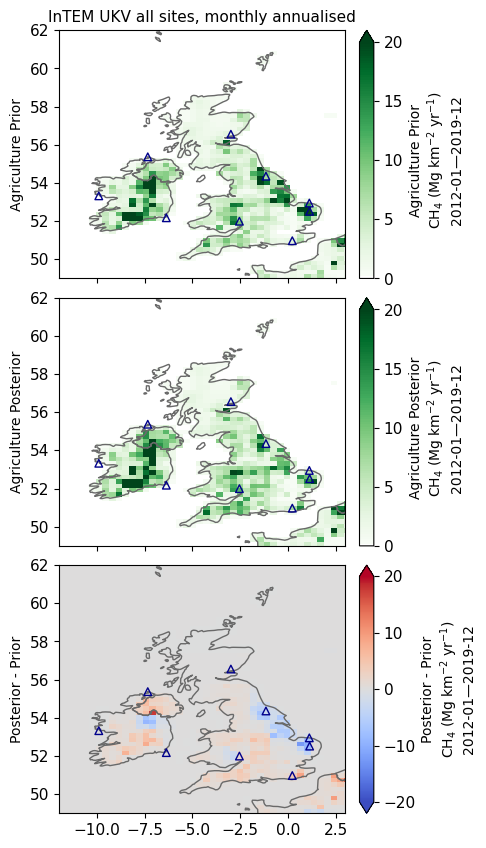

In [66]:
from fluxie.plots.flux_map import plot_flux_map
import matplotlib as mpl
import numpy as np
from matplotlib.colors import ListedColormap

###################################
### edit variables in this block
region = [-12,3,49,62] #[-15,30,40,70]
add_sites = True
add_markers = None # Add a marker at given locations, options for 'paris', 'london', ... or any value [lon, lat]
season = None # If specified, plot the seasonal mean (only valable for monthly data), options for 'DJF', 'MAM', 'JJA' and 'SON'
set_fluxlim = [0,20] # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
plot_inversion_grid_flux = False # If True, plot fluxes at inversion's resolution. If False, plot fluxes at prior's resolution.
sector = 'agriculture'     # default 'total', otherwise chosen single sector plotted for all models
include_title_and_labels = True # if False, simplifys plots by removing title, y axis label, lat/lon ticks and some info from cbar label
site_marker = '^' # Marker used for site locations in the flux map, default is triangle ('^')
city_marker = 'o' # Marker used for custom markers in the flux map (e.g. cities), default is circle ('o')
marker_color = 'darkblue'
###################################

greens_colors = mpl.colormaps['Greens'](np.linspace(0, 1, 100))
new_colors = np.vstack((np.array([[1, 1, 1, 1]]), greens_colors))
Greens_with_white = ListedColormap(new_colors)

fig = plot_flux_map(ds_all_flux_scaled, species, region, config_data, model_labels, season=season,
                    add_sites=add_sites, add_markers=add_markers, set_fluxlim=set_fluxlim, 
                    plot_inversion_grid_flux=plot_inversion_grid_flux,sector=sector,
                    include_title_and_labels=include_title_and_labels,site_marker=site_marker,city_marker=city_marker,
                    marker_color=marker_color,
                    cmap=Greens_with_white,c_border='dimgrey')

Save plot:

In [67]:
output_path = f'/home/users/alice.ramsden/plots/intem_sector_ch4/spatial_flux_scaling/InTEM_EDGARv2025_CEH_ERA5_spatial_2010-2020_{sector}.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Flux comparison between two models

In [ ]:
from fluxie.plots.flux_map import plot_flux_map_model_comparison
import matplotlib as mpl
import numpy as np
from matplotlib.colors import ListedColormap

###################################
### edit variables in this block
models_plot = models[:2]
region = [-15,30,40,70] #'UK'
sector = 'total'     # default 'total', otherwise chosen single sector plotted for all models
var = f'flux_{sector}_posterior_inversion_grid'
set_fluxlim = 'auto'
site_marker = '^' # Marker used for site locations in the flux map, default is triangle ('^')
city_marker = 'o' # Marker used for custom markers in the flux map (e.g. cities), default is circle ('o')
marker_color = 'darkblue'
###################################

greens_colors = mpl.colormaps['Greens'](np.linspace(0, 1, 100))
new_colors = np.vstack((np.array([[1, 1, 1, 1]]), greens_colors))
Greens_with_white = ListedColormap(new_colors)

fig = plot_flux_map_model_comparison(ds_all_flux_scaled, var, models_plot, species, region, config_data, model_labels, 
                                     season=season, add_sites=add_sites, add_markers=add_markers, 
                                     set_fluxlim=set_fluxlim,sector=sector,cmap=Greens_with_white,c_border='dimgrey',
                                     site_marker=site_marker,city_marker=city_marker,marker_color=marker_color)

Save plot:

In [ ]:
output_path = '/home/users/alice.ramsden/plots/intem_testing/country_masks/Mar2026_regions/sf6_spatial_flux_difference_new_regions_2025.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Plot prior, posterior or difference fluxes per time interval:

In [3]:
from fluxie.plots.flux_map import plot_flux_map_over_time
import matplotlib as mpl
import numpy as np
from matplotlib.colors import ListedColormap

region = 'UK' #[-12,4,49,62]
chop_by = 'year' # Time unit of the averaging period (options for 'year', 'month' and 'season').
                 # Alternatively, a list of starting dates can be provided (format '2018-01-01') or a list of months (e.g., [[1:3], [7:9]])
dt = 5  # Number of time steps for year and month chop_by options
plot_combined = False
add_sites = True    
add_markers = None #['london','birmingham','cardiff','manchester','edinburgh','belfast','dublin']
set_fluxlim = 'auto' #[0,1.5] # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
sector = 'total'     # default 'total', otherwise chosen single sector plotted for all models
var = f'flux_{sector}_posterior'  # Variable to be plotted. Extra options for 'posterior_prior_diff', 'posterior_mean_diff', 'posterior_prior_diff_inversion_grid', 'posterior_mean_diff_inversion_grid'.
add_gridlines = True    # If True, adds lat/lon gridlines
site_marker = '^' # Marker used for site locations in the flux map, default is triangle ('^')
city_marker = 'o' # Marker used for custom markers in the flux map (e.g. cities), default is circle ('o')
marker_color = 'darkblue'
###################################

greens_colors = mpl.colormaps['Greens'](np.linspace(0, 1, 100))
new_colors = np.vstack((np.array([[1, 1, 1, 1]]), greens_colors))
Greens_with_white = ListedColormap(new_colors)

fig = plot_flux_map_over_time(ds_all_flux_scaled, var, species,region,config_data, model_labels, chop_by=chop_by, dt=dt,
                              plot_combined=plot_combined, add_sites=add_sites, add_markers=add_markers, 
                              set_fluxlim = set_fluxlim,sector=sector,cmap=Greens_with_white,c_border='dimgrey',
                              include_title_and_labels=True,add_gridlines=add_gridlines,
                              site_marker=site_marker,city_marker=city_marker,marker_color=marker_color)

ValueError: Uncoherent `time_labels` derived : {'InTEM_ERA5_EUROPE_NID2026_G': ['1990—1994', '1995—1999', '2000—2004', '2005—2009', '2010—2011'], 'InTEM_NAME_EUROPE_AR2026': ['2012—2016', '2017—2021', '2022—2025']}. Most probable reason is difference between start and end dates of the datasets, slicing them to their common period should resolve the issue.

In [ ]:
output_path = '/home/users/alice.ramsden/home_intem_ghg/NID_2026/NID2025_comparison_plots/hfc245fa_spatial_flux_UK_2021-2024.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)


Save plot:

In [ ]:
#output_path = None
#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Flux comparison between two groups of models

In [ ]:
from fluxie.plots.flux_map import plot_flux_map_combined_models_comparison

###################################
### edit variables in this block
group_a = [models[0], models[1]] # List of model names to be combined for the first group.
group_b = [models[2]] # List of model names to be combined for the second group.
group_a_label = "Group A" # Label for the first group of combined models.
group_b_label = "Group B" # Label for the second group of combined models.
var = "flux_total_posterior_inversion_grid"
region = "FRA"
add_sites = False
add_markers = False
season = None
###################################

fig = plot_flux_map_combined_models_comparison(
    ds_all=ds_all_flux_scaled,
    var=var,
    group_a_models=group_a,
    group_b_models=group_b,
    species=species,
    region=region,
    config_data=config_data,
    group_a_label=group_a_label,
    group_b_label=group_b_label,
    add_sites=add_sites,
    add_markers=add_markers,
    season=season
)

### 4. Timeseries of country fluxes - stacked bar chart of all species

In [ ]:
from fluxie.io import read_model_output, read_flux_total_fgases
from fluxie.operators.select import slice_flux
from fluxie.config import set_model_colors,set_model_labels
from fluxie.plots.flux_timeseries import plot_all_species_stacked_bar

###################################
### edit variables in this block
all_species = ['nf3','sf6','all_pfc','all_hfc','n2o','ch4']
period = ['yearly','monthly','yearly','yearly','monthly','monthly'] #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
model = 'InTEM'
regions = 'UK'
country_flux_units_print = 'Tg CO2-eq yr-1' #desired units for the plot. Add "CO2-eq" to convert the mass to CO2 equivalent (e.g. "Gg CO2-eq yr-1")
start_date = '2013-01-01' #inclusive
end_date = '2026-01-01' #not inclusive
get_labels_from_file = True # If False, uses default labels. If True, uses labels in models_info.json.
sector_file = None  # if not None, adds sector level results by scaling model totals by the sector proportions in this file.
create_region_sector_totals = False #if True, uses country_fraction variable to sum spatial sector fluxes to region sector fluxes
read_standard_run = True
only_overlapping = True #if True, only uses time periods where all models have data
###################################

ds_all_flux = {}
ds_all_flux_scaled = {}

for s,species in enumerate(all_species):
    if 'all' in species:
        ds_all_flux_scaled[species] = read_flux_total_fgases(data_dir,species,[model],config_data,
                                                        regions,start_date,end_date,
                                                        period=period[s],only_overlapping=only_overlapping)
    else:
        ds_all_flux[species] = read_model_output(data_dir,"flux",species,[model],config_data,period=period[s],read_standard_run=read_standard_run)
        ds_all_flux_scaled[species] = slice_flux(ds_all_flux[species],config_data,start_date,end_date,species=species,country_flux_units_print=country_flux_units_print)

In [ ]:
y_lim = [0,122]

plot_inventory_uncertainty = True
inventory_years = ['2026']
inventory_filename = 'UNFCCC_inventory'

fig,flux_sum,uncert,inventory_sum,inventories_uncert,\
plot_times = plot_all_species_stacked_bar(all_species=all_species,
                                      ds_all_flux_scaled=ds_all_flux_scaled,
                                      regions=regions,
                                      config_data=config_data,
                                      start_date=start_date,
                                      end_date=end_date,
                                      inventory_years=inventory_years,
                                      inventory_filename=inventory_filename,
                                      plot_inventory_uncertainty=plot_inventory_uncertainty,
                                      data_dir=data_dir,
                                      y_lim=y_lim)

In [ ]:
output_path = None #'/home/users/alice.ramsden/home_intem_ghg/NID_2026/NID2025_comparison_plots/all_species_stacked_bar_chart_NID2026.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)